Nhiều nguồn dữ liệu chứa cả dữ liệu số và văn bản.

Chúng tôi có thể sử dụng văn bản để tạo các tính năng cho bất kỳ phương pháp dự đoán nào mà chúng tôi đã thảo luận.

Làm như vậy yêu cầu mã hóa văn bản thành một số biểu diễn số.

Một bảng mã tốt sẽ bảo toàn ý nghĩa của văn bản gốc, trong khi vẫn quản lý được kích thước.

Trong bài giảng này, chúng ta sẽ học cách làm việc với văn bản thông qua một ứng dụng - dự đoán tử vong từ các dự báo tuyết lở

Tuyết lở
Những trận lở tuyết là một mối nguy hiểm ở vùng núi. Các trận tuyết lở có thể được dự đoán một phần dựa trên điều kiện tuyết, thời tiết và địa hình. Avalanche Canada đưa ra các dự báo về tuyết lở hàng ngày cho các vùng miền núi khác nhau của Canada. Các dự báo này bao gồm 1-5 xếp hạng cho mỗi trong ba dải độ cao, cũng như mô tả bằng văn bản về các trận tuyết lở quan sát gần đây, băng tuyết và thời tiết. Avalanche Canada cũng duy trì một danh sách các sự cố tuyết lở chết người. Trong bài giảng này, chúng ta sẽ cố gắng dự đoán các sự cố chết người từ văn bản của các dự báo về tuyết lở. Vì sự cố chết người là rất hiếm, nhiệm vụ dự đoán này sẽ khá khó khăn.

Dữ liệu
Avalanche Canada có api json không ổn định. Api dường như được điều chỉnh phần lớn để hiển thị thông tin trên các trang web khác nhau của Avalanche Canada, điều này không giúp dễ dàng lấy được lượng lớn dữ liệu. Tuy nhiên, lấy thông tin từ API dễ dàng hơn so với việc tìm kiếm trang web. Nói chung, bất cứ khi nào bạn đang cân nhắc việc tìm kiếm một trang web, trước tiên bạn nên kiểm tra xem trang web đó có sẵn API hay không.



Dữ liệu sự cố

In [ ]:
# Get data on avalanche forecasts and incidents from Avalanche Canada
# Avalanche Canada has an unstable public api
# https://github.com/avalanche-canada/ac-web
# Since API might change, this code might break
import json
import os
import urllib.request
import pandas as pd
import time
import requests
import io
import zipfile
import warnings
import matplotlib as plt


# Incidents
url = "http://incidents.avalanche.ca/public/incidents/?format=json"
req = urllib.request.Request(url)
with urllib.request.urlopen(req) as response:
    result = json.loads(response.read().decode('utf-8'))
incident_list = result["results"]
while (result["next"] != None):
    req = urllib.request.Request(result["next"])
    with urllib.request.urlopen(req) as response:
        result = json.loads(response.read().decode('utf-8'))
    incident_list = incident_list + result["results"]
incidents_brief = pd.DataFrame.from_dict(incident_list,orient="columns")
pd.options.display.max_rows = 20
pd.options.display.max_columns = 8
incidents_brief

,id,date,location,location_province,group_activity,num_involved,num_injured,num_fatal
0,ba14a125-29f7-4432-97ad-73a53207a5e7,2021-04-05,Haddo Peak,AB,Skiing,2.0,0.0,1
1,59023c05-b679-4e9f-9c06-910021318663,2021-03-29,Eureka Peak,BC,Snowmobiling,1.0,0.0,1
2,10774b2d-b7de-42ac-a600-9828cb4e6129,2021-03-04,Reco Mountain,BC,Snowmobiling,1.0,0.0,1
3,4f79d4db-57b3-4843-909f-eaca3c499e7c,2021-02-23,Swift Creek,BC,Skiing,3.0,0.0,1
4,a6115fd5-b330-4424-b400-4bc218f387e1,2021-02-20,Hasler,BC,Snowmobiling,1.0,0.0,1
...,...,...,...,...,...,...,...,...
482,101c517b-29a4-4c49-8934-f6c56ddd882d,1840-02-01,Château-Richer,QC,Unknown,NaN,NaN,1
483,b2e1c50a-1533-4145-a1a2-0befca0154d5,1836-02-09,Quebec,QC,Unknown,NaN,NaN,1
484,18e8f963-da33-4682-9312-57ca2cc9ad8d,1833-05-24,Carbonear,NL,Unknown,NaN,0.0,1
485,083d22df-ed50-4687-b9ab-1649960a0fbe,1825-02-04,Saint-Joseph de Lévis,QC,Inside Building,NaN,NaN,5


In [ ]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
print('setup complete')
plt.style.use('seaborn-darkgrid')
palette=plt.get_cmap('Set2')

setup complete


In [ ]:
# We can get more information about these incidents e.g. "https://www.avalanche.ca/incidents/37d909e4-c6de-43f1-8416-57a34cd48255"
# this information is also available through the API
def get_incident_details(id):
    url = "http://incidents.avalanche.ca/public/incidents/{}?format=json".format(id)
    req = urllib.request.Request(url)
    with urllib.request.urlopen(req) as response:
        result = json.loads(response.read().decode('utf-8'))
    return(result)


incidentsfile = "avalanche_incidents.csv"

# To avoid loading the avalanche Canada servers, we save the incident details locally.
if (not os.path.isfile(incidentsfile)):
    incident_detail_list = incidents_brief.id.apply(get_incident_details).to_list()
    incidents = pd.DataFrame.from_dict(incident_detail_list, orient="columns")
    incidents.to_csv(incidentsfile)
else:
    incidents = pd.read_csv(incidentsfile)

incidents

,id,ob_date,location,location_desc,...,weather_comment,snowpack_obs,snowpack_comment,documents
0,ba14a125-29f7-4432-97ad-73a53207a5e7,2021-04-05,Haddo Peak,Approximately 6km SW of Lake Louise Village,...,,"{'hs': None, 'hn24': None, 'hst': None, 'hst_r...",,"[{'date': '2021-04-05', 'title': 'Overview pho..."
1,59023c05-b679-4e9f-9c06-910021318663,2021-03-29,Eureka Peak,Approximately 100km east of Williams Lake,...,,"{'hs': None, 'hn24': None, 'hst': None, 'hst_r...",,"[{'date': '2021-04-01', 'title': 'Overview', '..."
2,10774b2d-b7de-42ac-a600-9828cb4e6129,2021-03-04,Reco Mountain,Approximately 13km east of New Denver,...,,"{'hs': None, 'hn24': None, 'hst': None, 'hst_r...",,"[{'date': '2021-03-05', 'title': 'Scene Overvi..."
3,4f79d4db-57b3-4843-909f-eaca3c499e7c,2021-02-23,Swift Creek,Approximately 16km NE of Valemount,...,,"{'hs': None, 'hn24': None, 'hst': None, 'hst_r...",,"[{'date': '2021-02-25', 'title': 'Overview wit..."
4,a6115fd5-b330-4424-b400-4bc218f387e1,2021-02-20,Hasler,Approximately 55km SW of Chetwynd,...,,"{'hs': None, 'hn24': None, 'hst': None, 'hst_r...",,[]
...,...,...,...,...,...,...,...,...,...
482,101c517b-29a4-4c49-8934-f6c56ddd882d,1840-02-01,Château-Richer,,...,,"{'hs': None, 'hn24': None, 'hst': None, 'hst_r...",,[]
483,b2e1c50a-1533-4145-a1a2-0befca0154d5,1836-02-09,Quebec,more details unknown,...,,"{'hs': None, 'hn24': None, 'hst': None, 'hst_r...",,[]
484,18e8f963-da33-4682-9312-57ca2cc9ad8d,1833-05-24,Carbonear,,...,,"{'hs': None, 'hn24': None, 'hst': None, 'hst_r...",,"[{'title': 'Carbonear, May 24, 1833', 'source'..."
485,083d22df-ed50-4687-b9ab-1649960a0fbe,1825-02-04,Saint-Joseph de Lévis,Pointe Lévis,...,,"{'hs': None, 'hn24': None, 'hst': None, 'hst_r...",,[]


In [ ]:
incidents.head(10)

,id,ob_date,location,location_desc,...,weather_comment,snowpack_obs,snowpack_comment,documents
0,ba14a125-29f7-4432-97ad-73a53207a5e7,2021-04-05,Haddo Peak,Approximately 6km SW of Lake Louise Village,...,,"{'hs': None, 'hn24': None, 'hst': None, 'hst_r...",,"[{'date': '2021-04-05', 'title': 'Overview pho..."
1,59023c05-b679-4e9f-9c06-910021318663,2021-03-29,Eureka Peak,Approximately 100km east of Williams Lake,...,,"{'hs': None, 'hn24': None, 'hst': None, 'hst_r...",,"[{'date': '2021-04-01', 'title': 'Overview', '..."
2,10774b2d-b7de-42ac-a600-9828cb4e6129,2021-03-04,Reco Mountain,Approximately 13km east of New Denver,...,,"{'hs': None, 'hn24': None, 'hst': None, 'hst_r...",,"[{'date': '2021-03-05', 'title': 'Scene Overvi..."
3,4f79d4db-57b3-4843-909f-eaca3c499e7c,2021-02-23,Swift Creek,Approximately 16km NE of Valemount,...,,"{'hs': None, 'hn24': None, 'hst': None, 'hst_r...",,"[{'date': '2021-02-25', 'title': 'Overview wit..."
4,a6115fd5-b330-4424-b400-4bc218f387e1,2021-02-20,Hasler,Approximately 55km SW of Chetwynd,...,,"{'hs': None, 'hn24': None, 'hst': None, 'hst_r...",,[]
5,fcc48775-35f2-4236-9d76-80dcd933f6f9,2021-02-13,Brandywine Bowl,Approximately 17km W of Whistler Village,...,,"{'hs': None, 'hn24': None, 'hst': None, 'hst_r...",,[]
6,17bcbc38-ccf8-4f32-ab5e-7b32315690af,2021-02-12,Phalanx Mountain,Approximately 6km NE of Whislter Village,...,,"{'hs': None, 'hn24': None, 'hst': None, 'hst_r...",,[]
7,e378a68a-bdc1-4935-9e1f-eb855f5e3f0e,2020-12-28,Railroad Pass,Above Hurley FSR approx 1km SE of Railroad Pas...,...,,"{'hs': None, 'hn24': None, 'hst': None, 'hst_r...",Snowpack investigation at the site of the aval...,"[{'date': '2020-12-29', 'title': 'Path 3', 'so..."
8,c197647d-f62e-429f-8a5e-3e86b86fe352,2020-11-28,Pine Pass - Bijou Falls,"Approximately 20 km east of Mackenzie, BC",...,Weather recordings were taken from Link Creek ...,"{'hs': 160, 'hn24': None, 'hst': None, 'hst_re...",100 cm 1F+ to P resistance snow overlay a thic...,"[{'date': '2020-11-29', 'title': 'Profile by S..."
9,dd556e1a-90f6-46a9-a31b-02508504f2d7,2020-03-14,Brunswick Mountain,Approximately 4km NE of Lions Bay British Colu...,...,,"{'hs': None, 'hn24': None, 'hst': None, 'hst_r...",,[]


Nhiều sự cố bao gồm cả tọa độ, nhưng những sự cố khác thì không. Tuy nhiên, hầu hết bao gồm một tên địa điểm. Chúng tôi có thể sử dụng Natural Resources Canada’s Geolocation Service để truy xuất tọa độ từ tên địa điểm.

In [ ]:
# geocode locations without coordinates
def geolocate(location, province):
    url = "http://geogratis.gc.ca/services/geolocation/en/locate?q={},%20{}"
    req = urllib.request.Request(url.format(urllib.parse.quote(location),province))
    with urllib.request.urlopen(req) as response:
        result = json.loads(response.read().decode('utf-8'))
    if (len(result)==0):
        return([None,None])
    else:
        return(result[0]['geometry']['coordinates'])
if not "alt_coord" in incidents.columns:
    incidents["alt_coord"] = [
        geolocate(incidents.location[i], incidents.location_province[i])
        for i in incidents.index
    ]
    incidents.to_csv(incidentsfile)

Bây giờ chúng ta đã có dữ liệu sự cố, hãy tạo một số số liệu.

In [ ]:
incidents.group_activity.unique()

array(['Skiing', 'Snowmobiling', 'Skiing/Snowboarding', 'Snow Biking',
       'Snowshoeing', 'Snowboarding', 'Backcountry Skiing',
       'Ice Climbing', 'Ski touring', 'Heliskiing',
       'Snowshoeing & Hiking', 'Mechanized Skiing', 'Work',
       'Mountaineering', 'Other Recreational', 'Out-of-bounds Skiing',
       'At Outdoor Worksite', 'Lift Skiing Closed', 'Lift Skiing Open',
       'Hunting/Fishing', 'Out-of-Bounds Skiing', 'Control Work',
       'Inside Building', 'Car/Truck on Road', 'Inside Car/Truck on Road',
       'Unknown', 'Outside Building'], dtype=object)

In [ ]:
import matplotlib.pyplot as plt

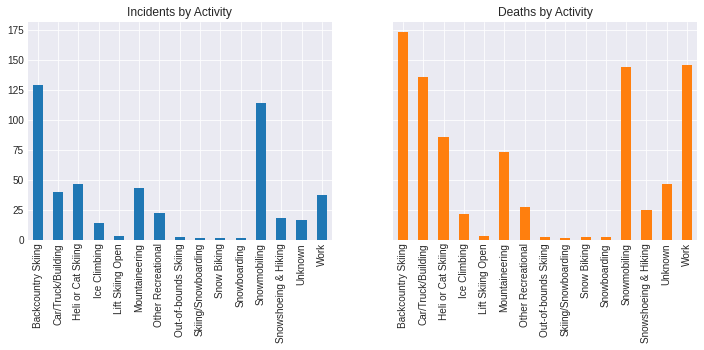

In [ ]:
incidents.group_activity=incidents.group_activity.replace("Ski touring","Backcountry Skiing")
incidents.group_activity=incidents.group_activity.replace("Out-of-Bounds Skiing","Backcountry Skiing")
incidents.group_activity=incidents.group_activity.replace("Lift Skiing Closed","Backcountry Skiing")
incidents.group_activity=incidents.group_activity.replace("Skiing","Backcountry Skiing")
incidents.group_activity=incidents.group_activity.replace("Snowshoeing","Snowshoeing & Hiking")
incidents.group_activity=incidents.group_activity.replace("Snowshoeing and Hiking","Snowshoeing & Hiking")
incidents.group_activity=incidents.group_activity.replace("Mechanized Skiing","Heli or Cat Skiing")
incidents.group_activity=incidents.group_activity.replace("Heliskiing","Heli or Cat Skiing")
incidents.group_activity=incidents.group_activity.replace("At Outdoor Worksite","Work")
incidents.group_activity=incidents.group_activity.replace("Control Work","Work")
incidents.group_activity=incidents.group_activity.replace("Hunting/Fishing","Other Recreational")
incidents.group_activity=incidents.group_activity.replace("Inside Car/Truck on Road","Car/Truck/Building")
incidents.group_activity=incidents.group_activity.replace("Car/Truck on Road","Car/Truck/Building")
incidents.group_activity=incidents.group_activity.replace("Inside Building","Car/Truck/Building")
incidents.group_activity=incidents.group_activity.replace("Outside Building","Car/Truck/Building")


incidents.group_activity.unique()

fig, ax = plt.subplots(1,2, sharey=True, figsize=(12,4))
colors=plt.rcParams["axes.prop_cycle"].by_key()["color"]
incidents.groupby(['group_activity']).id.count().plot(kind='bar', title="Incidents by Activity", ax=ax[0])
incidents.groupby(['group_activity']).num_fatal.sum().plot(kind='bar', title="Deaths by Activity", ax=ax[1], color=colors[1])
ax[0].set_xlabel(None)
ax[1].set_xlabel(None);

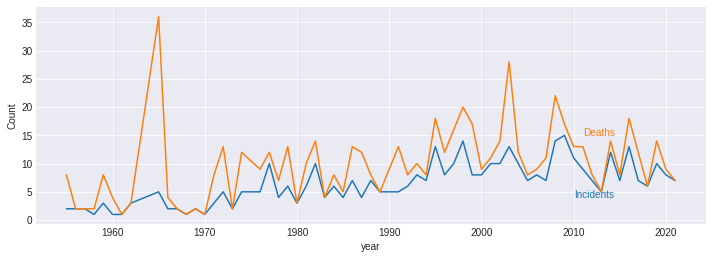

In [ ]:
incidents["date"] = pd.to_datetime(incidents.ob_date)
incidents["year"] = incidents.date.apply(lambda x: x.year)
incidents.date = incidents.date.dt.date
colors=plt.rcParams["axes.prop_cycle"].by_key()["color"]
f = incidents.groupby(["year"]).num_fatal.sum()
n = incidents.groupby(["year"]).id.count()
yearstart=1950
f=f[f.index>yearstart]
n=n[n.index>yearstart]
fig,ax = plt.subplots(1,1,figsize=(12,4))
n.plot(ax=ax)
f.plot(ax=ax)
ax.set_ylabel("Count")
ax.annotate("Incidents", (2010, 4), color=colors[0])
ax.annotate("Deaths", (2011, 15), color=colors[1]);

Sự cố lập bản đồ
Vì dữ liệu sự cố bao gồm các tọa độ, chúng tôi cũng có thể tạo một bản đồ. Thật không may, một số vĩ độ và kinh độ có sai số rõ ràng. Ở đây, chúng tôi cố gắng sửa chữa chúng.

In [ ]:
import re

# fix errors in latitude, longitude
latlon = incidents.location_coords
def makenumeric(cstr):
    if cstr is None:
        return([None,None])
    elif (type(cstr)==str):
        return([float(s) for s in re.findall(r'-?\d+\.?\d*',cstr)])
    else:
        return(cstr)

latlon = latlon.apply(makenumeric)

def good_lat(lat):
    return(lat >= 41.6 and lat <= 83.12) # min & max for Canada

def good_lon(lon):
    return(lon >= -141 and lon<= -52.6)

def fixlatlon(c):
    if (len(c)<2 or type(c[0])!=float or type(c[1])!=float):
        c = [None, None]
        return(c)
    lat = c[0]
    lon = c[1]
    if not good_lat(lat) and good_lat(lon):
        tmp = lat
        lat = lon
        lon = tmp
    if not good_lon(lon) and good_lon(-lon):
        lon = -lon
    if not good_lon(lon) and good_lon(lat):
        tmp = lat
        lat = lon
        lon = tmp
    if not good_lon(lon) and good_lon(-lat):
        tmp = -lat
        lat = lon
        lon = tmp
    if not good_lat(lat) or not good_lon(lon):
        c[0] = None
        c[1] = None
    else:
        c[0] = lat
        c[1] = lon
    return(c)

incidents["latlon"] = latlon.apply(fixlatlon)

In [ ]:
def foo(c, a):
    if (type(a)==str):
        a = [float(s) for s in re.findall(r'-?\d+\.?\d*',a)]
    if len(a) <2:
        a = [None,None]
    return([a[1],a[0]] if type(c[0])!=float else c)
incidents["latlon_filled"]=[foo(c,a) for c,a in zip(incidents["latlon"],incidents["alt_coord"])]
nmiss = sum([a[0]==None for a in incidents.latlon_filled])
n = len(incidents.latlon_filled)
print("{} of {} incidents have latitude & longitude".format(n-nmiss, n))

326 of 487 incidents have latitude & longitude


In [ ]:
# download forecast region definitions
# req = urllib.request.Request("https://www.avalanche.ca/api/forecasts")
# The above link doesn't work since COVID-19 lockdown. Currently we use an old cached version instead
#req = ("https://web.archive.org/web/20150319031605if_/http://www.avalanche.ca/api/forecasts")
#with urllib.request.urlopen(req) as response:
#    forecastregions = json.loads(response.read().decode('utf-8'))
req = "https://faculty.arts.ubc.ca/pschrimpf/forecast-regions2015.json"
with urllib.request.urlopen(req) as response:
    regions2015 = json.loads(response.read().decode('utf-8'))

req = "https://faculty.arts.ubc.ca/pschrimpf/forecast-regions2019.json"
with urllib.request.urlopen(req) as response:
    regions2019 = json.loads(response.read().decode('utf-8'))

forecastregions = regions2019
ids = [r['id'] for r in forecastregions['features']]
for r in regions2015['features'] :
     if not r['id'] in ids :
            forecastregions['features'].append(r)

Bạn có thể phải bỏ ghi chú dòng thứ hai bên dưới nếu folium chưa được cài đặt.

In [ ]:
# Map forecast regions and incidents
#!pip install --user folium
import folium
import matplotlib

cmap = matplotlib.cm.get_cmap('Set1')
fmap = folium.Map(location=[60, -98],
                            zoom_start=3,
                            tiles='Stamen Terrain')
with urllib.request.urlopen(req) as response:
    regions_tmp = json.loads(response.read().decode('utf-8'))
folium.GeoJson(regions_tmp,
               tooltip=folium.GeoJsonTooltip(fields=["name"], aliases=[""]),
               highlight_function=lambda x: { 'weight': 10},
              style_function=lambda x: {'weight':1}).add_to(fmap)
activities = incidents.group_activity.unique()
for i in incidents.index:
    if incidents.latlon_filled[i][0] is not None and  incidents.latlon_filled[i][1] is not None:
        cindex=[j for j,x in enumerate(activities) if x==incidents.group_activity[i]][0]
        txt = "{}, {}<br>{} deaths"
        txt = txt.format(incidents.group_activity[i],
                        incidents.ob_date[i],
                        incidents.num_fatal[i]
                        )
        pop = folium.Popup(incidents.comment[i], parse_html=True, max_width=400)
        folium.CircleMarker(incidents.latlon_filled[i],
                      tooltip=txt,
                      popup=pop,
                      color=matplotlib.colors.to_hex(cmap(cindex)), fill=True, radius=5).add_to(fmap)
fmap

Hãy dành một chút thời gian để nhấp vào bản đồ và đọc về một số sự cố.

Giữa việc hiển thị thông tin này trên bản đồ và danh sách trên https://www.avalanche.ca/incident/, bạn thích cái nào hơn và tại sao?

Khớp các sự cố với các khu vực
Sau đó, chúng tôi sẽ muốn đối sánh sự cố với dự báo, vì vậy hãy tìm khu vực gần nhất với từng sự cố.

Lưu ý rằng khoảng cách ở đây sẽ được tính bằng đơn vị vĩ độ, kinh độ (hoặc bất kỳ hệ tọa độ nào mà chúng tôi sử dụng). Tại đường xích đạo, khoảng cách 1 là khoảng 60 hải lý.

Vì các đường kinh độ càng gần nhau càng xa đường xích đạo, nên những khoảng cách này sẽ bị đánh giá thấp hơn khi bạn đi xa hơn về phía Bắc.

Đây không phải là vấn đề nhiều nếu chúng ta chỉ tìm vùng gần nhất, nhưng nếu chúng ta quan tâm đến khoảng cách chính xác, chúng ta nên chiếu lại vĩ độ và kinh độ thành một hệ tọa độ khác.

In [ ]:
# Match incidents to nearest forecast regions.
from shapely.geometry import Point, Polygon, shape
point = Point(incidents.latlon_filled[0][1],incidents.latlon_filled[0][0])
def distances(latlon):
    point=Point(latlon[1],latlon[0])
    df = pd.DataFrame.from_dict([{'id':feature['id'],
                                  'distance':shape(feature['geometry']).distance(point)} for
                                 feature in forecastregions['features']])
    return(df)
def foo(x):
    if (x[0]==None):
        return(None)
    d = distances(x)
    return(d.id[d.distance.idxmin()])
incidents['nearest_region'] = incidents.latlon_filled.apply(foo)
incidents['nearest_distance'] = incidents.latlon_filled.apply(lambda x: None if x[0]==None else distances(x).distance.min())

In [ ]:
incidents

,id,ob_date,location,location_desc,...,latlon,latlon_filled,nearest_region,nearest_distance
0,ba14a125-29f7-4432-97ad-73a53207a5e7,2021-04-05,Haddo Peak,Approximately 6km SW of Lake Louise Village,...,"[51.38329, -116.23453]","[51.38329, -116.23453]",banff-yoho-kootenay,0.000000
1,59023c05-b679-4e9f-9c06-910021318663,2021-03-29,Eureka Peak,Approximately 100km east of Williams Lake,...,"[52.33517, -120.69033]","[52.33517, -120.69033]",cariboos,0.000000
2,10774b2d-b7de-42ac-a600-9828cb4e6129,2021-03-04,Reco Mountain,Approximately 13km east of New Denver,...,"[49.99979, -117.18904]","[49.99979, -117.18904]",south-columbia,0.000000
3,4f79d4db-57b3-4843-909f-eaca3c499e7c,2021-02-23,Swift Creek,Approximately 16km NE of Valemount,...,"[52.917303, -119.081732]","[52.917303, -119.081732]",north-rockies,0.086401
4,a6115fd5-b330-4424-b400-4bc218f387e1,2021-02-20,Hasler,Approximately 55km SW of Chetwynd,...,"[55.3377373, -122.256577]","[55.3377373, -122.256577]",north-rockies,0.000000
...,...,...,...,...,...,...,...,...,...
482,101c517b-29a4-4c49-8934-f6c56ddd882d,1840-02-01,Château-Richer,,...,"[None, None]","[46.9666667, -71.0166667]",chic-chocs,5.145266
483,b2e1c50a-1533-4145-a1a2-0befca0154d5,1836-02-09,Quebec,more details unknown,...,"[None, None]","[46.813819, -71.207997]",chic-chocs,5.380364
484,18e8f963-da33-4682-9312-57ca2cc9ad8d,1833-05-24,Carbonear,,...,"[47.733333587646484, -53.21666717529297]","[47.733333587646484, -53.21666717529297]",chic-chocs,12.827272
485,083d22df-ed50-4687-b9ab-1649960a0fbe,1825-02-04,Saint-Joseph de Lévis,Pointe Lévis,...,"[None, None]","[46.8105556, -71.1819444]",chic-chocs,5.357613


Dữ liệu dự báo
Giờ đây, chúng tôi sẽ tải xuống tất cả dự báo cho tất cả các khu vực kể từ tháng 11 năm 2011 (gần như là dữ liệu sớm nhất có sẵn).

Chúng tôi chỉ có thể yêu cầu một dự báo tại một thời điểm, do đó, quá trình này sẽ mất nhiều giờ để tải xuống.

Để làm cho quá trình này chạy nhanh hơn cho người đọc, chúng tôi đã tự chạy mã và sau đó lưu trữ dữ liệu trên đám mây.

Hàm bên dưới sẽ tìm nạp tất cả các dự báo từ vị trí lưu trữ đám mây và lưu chúng vào một thư mục có tên avalanche_forecasts.

In [ ]:
def download_cached_forecasts():
    # download the zipped file and unzip it here
    url = "https://datascience.quantecon.org/assets/data/avalanche_forecasts.zip"
    with requests.get(url) as res:
        if not res.ok:
            raise ValueError("failed to download the cached forecasts")
        with zipfile.ZipFile(io.BytesIO(res.content)) as z:
            for f in z.namelist():
                if (os.path.isfile(f) and z.getinfo(f).file_size < os.stat(f).st_size):
                    warnings.warn(f"'File $f exists and is larger than version in cache. Not replacing.")
                else :
                    z.extract(f)

download_cached_forecasts()

Đoạn mã dưới đây là những gì chúng tôi đã chạy ban đầu để có được tất cả các dự báo.

Bạn sẽ nhận thấy rằng mã này kiểm tra xem liệu có thể tìm thấy các tệp trong thư mục avalanche_forecasts hay không (chúng có thể làm được nếu bạn chạy download_cached_forecasts ở trên!) Và sẽ chỉ tải xuống nếu không tìm thấy chúng.

Bạn có thể thử nghiệm với bộ nhớ đệm này bằng cách xóa một hoặc nhiều tệp khỏi thư mục avalanche_forecasts và chạy lại các ô bên dưới.

In [ ]:
# Functions for downloading forecasts from Avalanche Canada

def get_forecast(date, region):
    url = "https://www.avalanche.ca/api/bulletin-archive/{}/{}.json".format(date.isoformat(),region)
    try:
        req = urllib.request.Request(url)
        with urllib.request.urlopen(req) as response:
            result = json.loads(response.read().decode('utf-8'))
        return(result)
    except:
        return(None)

def get_forecasts(start, end, region):
    day = start
    forecasts = []
    while(day<=end and day<end.today()):
        #print("working on {}, {}".format(region,day))
        forecasts = forecasts + [get_forecast(day, region)]
        #print("sleeping")
        time.sleep(0.1) # to avoid too much load on Avalanche Canada servers
        day = day + pd.Timedelta(1,"D")
    return(forecasts)

def get_season(year, region):
    start_month = 11
    start_day = 20
    last_month = 5
    last_day = 1
    if (not os.path.isdir("avalanche_forecasts")):
        os.mkdir("avalanche_forecasts")
    seasonfile = "avalanche_forecasts/{}_{}-{}.json".format(region, year, year+1)
    if (not os.path.isfile(seasonfile)):
        startdate = pd.to_datetime("{}-{}-{} 12:00".format(year, start_month, start_day))
        lastdate = pd.to_datetime("{}-{}-{} 12:00".format(year+1, last_month, last_day))
        season = get_forecasts(startdate,lastdate,region)
        with open(seasonfile, 'w') as outfile:
            json.dump(season, outfile, ensure_ascii=False)
    else:
        with open(seasonfile, "rb") as json_data:
            season = json.load(json_data)
    return(season)

In [ ]:
forecastlist=[]

for year in range(2011,2019):
    print("working on {}".format(year))
    for region in [region["id"] for region in forecastregions["features"]]:
        forecastlist = forecastlist + get_season(year, region)

working on 2011
working on 2012
working on 2013
working on 2014
working on 2015
working on 2016
working on 2017
working on 2018


In [ ]:
# convert to DataFrame and extract some variables
forecasts = pd.DataFrame.from_dict([f for f in forecastlist if not f==None],orient="columns")

forecasts["danger_date"] = forecasts.dangerRatings.apply(lambda r: r[0]["date"])
forecasts["danger_date"] = pd.to_datetime(forecasts.danger_date, utc=True).dt.date
forecasts["danger_alpine"]=forecasts.dangerRatings.apply(lambda r: r[0]["dangerRating"]["alp"])
forecasts["danger_treeline"]=forecasts.dangerRatings.apply(lambda r: r[0]["dangerRating"]["tln"])
forecasts["danger_belowtree"]=forecasts.dangerRatings.apply(lambda r: r[0]["dangerRating"]["btl"])

In [ ]:
forecasts.head()

,id,region,dateIssued,validUntil,...,danger_date,danger_alpine,danger_treeline,danger_belowtree
0,bid_29924,northwest-coastal,2011-11-20T00:49:00.000Z,2011-11-21T00:00:00.000Z,...,2011-11-21,2:Moderate,2:Moderate,1:Low
1,bid_29943,northwest-coastal,2011-11-21T01:00:00.000Z,2011-11-22T00:00:00.000Z,...,2011-11-22,3:Considerable,3:Considerable,2:Moderate
2,bid_29965,northwest-coastal,2011-11-22T01:43:00.000Z,2011-11-23T00:00:00.000Z,...,2011-11-23,4:High,4:High,3:Considerable
3,bid_30080,northwest-coastal,2011-11-23T01:38:00.000Z,2011-11-24T00:00:00.000Z,...,2011-11-24,4:High,4:High,3:Considerable
4,bid_30358,northwest-coastal,2011-11-24T00:55:00.000Z,2011-11-25T00:00:00.000Z,...,2011-11-25,4:High,4:High,3:Considerable


In [ ]:
# merge incidents to forecasts
adf = pd.merge(forecasts, incidents, how="left",
               left_on=["region","danger_date"],
               right_on=["nearest_region","date"],
              indicator=True)
adf["incident"] = adf._merge=="both"
print("There were {} incidents matched with forecasts data. These occured on {}% of day-regions with forecasts".format(adf.incident.sum(),adf.incident.mean()*100))

There were 39 incidents matched with forecasts data. These occured on 0.26666666666666666% of day-regions with forecasts


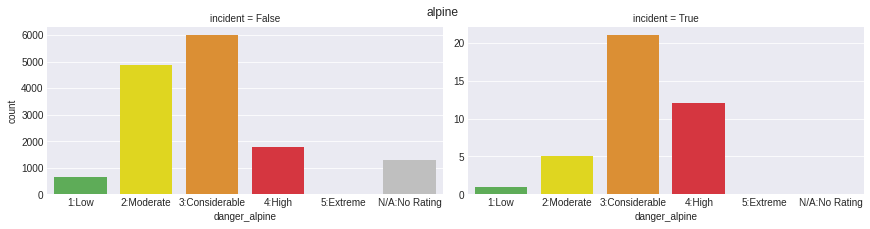

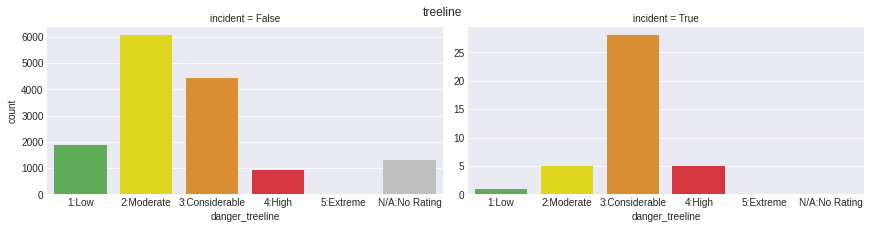

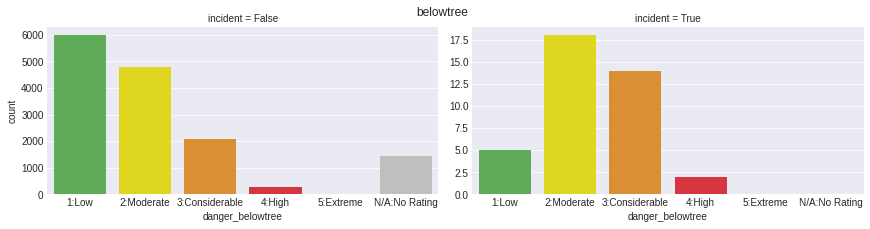

In [ ]:
import seaborn as sns
ratings=sorted(adf.danger_alpine.unique())
ava_colors = ["#52BA4A", "#FFF300", "#F79218", "#EF1C29", "#1A1A1A", "#BFBFBF"]
for x in ["danger_alpine", "danger_treeline", "danger_belowtree"]:
    fig=sns.catplot(x=x, kind="count",col="incident", order=ratings, data=adf, sharey=False,
                    palette=ava_colors, height=3, aspect=2)
    #plt.subplots_adjust(top=0.9)
    fig.fig.suptitle(x.replace("danger_",""))
    display(fig)

Sơ chế
Bước đầu tiên khi sử dụng văn bản làm dữ liệu là xử lý trước văn bản.

Trong quá trình tiền xử lý, chúng tôi sẽ:

Sạch sẽ: Loại bỏ các dấu câu và ký tự không phải văn bản không mong muốn.
Tokenize: Chia nhỏ các câu thành các từ.
Xóa “từ dừng”: Loại bỏ các từ phổ biến thực sự không cung cấp thông tin, như “a” và “the”.
Bổ đề hóa các từ: Giảm các từ trong từ điển của chúng “bổ đề”, ví dụ: "Snowing" và "snowed" đều trở thành tuyết (động từ).

In [ ]:
from bs4 import BeautifulSoup
import nltk
import string
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
# Remove stopwords (the, a, is, etc)
stopwords = set(nltk.corpus.stopwords.words('english'))
stopwords=stopwords.union(set(string.punctuation))
# Lemmatize words e.g. snowed and snowing are both snow (verb)
wnl = nltk.WordNetLemmatizer()
def text_prep(txt):
    soup = BeautifulSoup(txt, "lxml")
    [s.extract() for s in soup('style')] # remove css
    txt=soup.text # remove html tags
    txt = txt.lower()
    tokens = [token for token in nltk.tokenize.word_tokenize(txt)]
    tokens = [token for token in tokens if not token in stopwords]
    #tokens = [token for token in tokens if not token ]
    tokens = [wnl.lemmatize(token) for token in tokens]
    if (len(tokens)==0):
        tokens = ["EMPTYSTRING"]
    return(tokens)

text_prep(forecasts.highlights[1000])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


['avalanche',
 'danger',
 'could',
 'spike',
 'high',
 'slope',
 'getting',
 'baked',
 'sun',
 'avoid',
 'traveling',
 'underneath',
 'area']

In [ ]:
text_data = [text_prep(txt) for txt in adf.avalancheSummary]

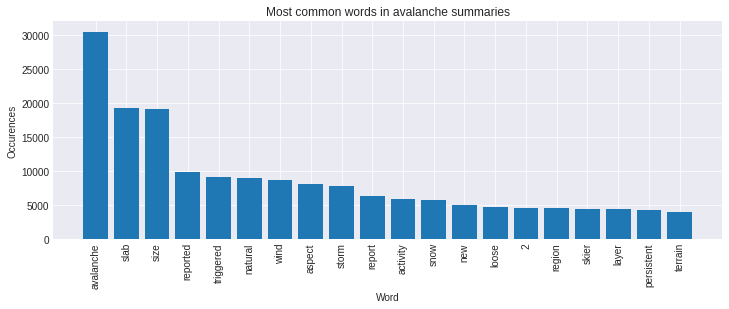

In [ ]:
wf = nltk.FreqDist([word for doc in text_data for word in doc]).most_common(20)
words = [x[0] for x in wf]
cnt = [x[1] for x in wf]

fig, ax = plt.subplots(figsize=(12,4))
ax.bar(range(len(words)), cnt);
ax.set_xticks(range(len(words)));
ax.set_xticklabels(words, rotation='vertical');
ax.set_title('Most common words in avalanche summaries');
ax.set_xlabel('Word');
ax.set_ylabel('Occurences');
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
vectorizer = CountVectorizer(max_features=500, min_df=5, max_df=0.7)
text_data = [text_prep(txt) for txt in adf.avalancheSummary]
y = adf.incident
X = vectorizer.fit_transform([' '.join(doc) for doc in text_data])

In [ ]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.3, random_state=124)
from sklearn import naive_bayes
classifier = naive_bayes.MultinomialNB()
classifier.fit(Xtrain,ytrain)
np.mean(classifier.predict(Xtest)==ytest)

0.9931631722880584

In [ ]:
from sklearn import metrics
print(metrics.confusion_matrix(ytest, classifier.predict(Xtest)))
print(metrics.classification_report(ytest, classifier.predict(Xtest)))

[[4357   19]
 [  11    1]]
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      4376
        True       0.05      0.08      0.06        12

    accuracy                           0.99      4388
   macro avg       0.52      0.54      0.53      4388
weighted avg       0.99      0.99      0.99      4388



A common text data classifier is the Naive Bayes classifier. This classifier predicts incidents using Bayes’ rules.

P(incident|words)=P(words|incident)P(incidents)P(words)
The classifier is naive, though; it assumes words are independent of one another in any given incident.

P(words|incident)=∏w∈wordsP(w|incident)

In [ ]:
# print text with highest predicted probabilities
phat=classifier.predict_proba(X)[:,1]
def remove_html(txt):
    soup = BeautifulSoup(txt, "lxml")
    [s.extract() for s in soup('style')] # remove css
    return(soup.text)
docs = [remove_html(txt) for txt in adf.avalancheSummary]
txt_high = [(_,x) for _, x in sorted(zip(phat,docs), key=lambda pair: pair[0],reverse=True)]
txt_high[:10]

[(0.9996933795791444,
  "In the dogtooth backcountry, observers reported a size 2.5 avalanche with a crown 1m+ in depth, that was likely human triggered.  Remote triggering of avalanches continues to be reported from the region.  Explosive control work once again produced large avalanches to size 3.5 on all aspects with crowns ranging from 40 - 120 in depth.I've left the previous narratives in from earlier this because they help to illustrate the nature of the current hazard. From Thursday:  Lots of avalanche activity to report from the region.  In the north Moderate to Strong NW winds at ridge top continued to load lee slopes resulting in a natural avalanche cycle to size 2.5 with crown depths 20 - 60cm in depth.  Just south of Golden explosive control work produced spectacular results with avalanches to size 3.5 & crown depths 100 - 160cm in depth.  All aspects at & above treeline were involved with the majority of the failures occurring on the early Feb. surface hoar.  In the centra

In [ ]:
# print text with lowest predicted probabilities
txt_low = [(_,x) for _, x in sorted(zip(phat,docs), key=lambda pair: pair[0])]
txt_low[:10]

[(2.3543721444156442e-20,
  'An early report from Wednesday includes a natural size 3 cornice triggered avalanche and a natural size 3 wet slab avalanche at 2200-2400 m elevation. On Tuesday, natural avalanche activity was reported in many parts of the region. Most of this activity was wet slabs up to size 3 and loose wet avalanches up to size 2 in response to the high elevation rain. A natural size 2.5 persistent slab avalanche was also observed on an east and southeast aspect slope at 2200 m in the area south of Nelson which failed on a layer down 50 cm. Ski cutting on Tuesday morning triggered several storm slab up to size 1.5 and explosives triggered numerous wet slab avalanches up to size 2.5 in the afternoon. On Thursday, if the sun comes out in full force, it will further destabilize an already warm snowpack. Natural loose wet and wet slab avalanches remain possible on steep sun exposed slopes. Large persistent slab avalanches also remain a serious concern until the snowpack has

In [ ]:
# LSA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
tfidf_vectorizer = TfidfVectorizer(use_idf=True, smooth_idf=True)
X = tfidf_vectorizer.fit_transform([' '.join(doc) for doc in text_data])

In [ ]:
svd_model = TruncatedSVD(n_components=10, algorithm='randomized', n_iter=100, random_state=122)
svd_model.fit(X)

TruncatedSVD(algorithm='randomized', n_components=10, n_iter=100,
             random_state=122, tol=0.0)

In [ ]:
print(svd_model.explained_variance_ratio_)
print(svd_model.explained_variance_ratio_.cumsum())
terms = tfidf_vectorizer.get_feature_names()
comp_label=[]
for i, comp in enumerate(svd_model.components_):
    terms_comp = zip(terms, comp)
    sorted_terms = sorted(terms_comp, key= lambda x:x[1], reverse=True)[:7]
    print("Topic "+str(i)+": ")
    message = ""
    for t in sorted_terms:
        message = message + "{:.2f} * {} + ".format(t[1],t[0])
    print(message)
    comp_label.append(message)

[0.01381632 0.03554643 0.03357845 0.01686496 0.01410331 0.01372541
 0.01263702 0.01076714 0.01056195 0.00848458]
[0.01381632 0.04936276 0.08294121 0.09980617 0.11390948 0.12763489
 0.14027191 0.15103905 0.161601   0.17008558]
Topic 0: 
0.38 * avalanche + 0.27 * size + 0.26 * slab + 0.25 * reported + 0.21 * new + 0.18 * triggered + 0.17 * wind + 
Topic 1: 
0.69 * new + 0.38 * reported + 0.24 * avalanche + 0.11 * observation + 0.10 * activity + 0.09 * observed + 0.09 * region + 
Topic 2: 
1.00 * emptystring + 0.00 * size + 0.00 * slab + 0.00 * recent + 0.00 * triggered + 0.00 * aspect + 0.00 * storm + 
Topic 3: 
0.43 * recent + 0.41 * observation + 0.25 * please + 0.25 * information + 0.25 * mountain + 0.22 * network + 0.18 * region + 
Topic 4: 
0.43 * reported + 0.40 * recent + 0.21 * loose + 0.16 * wet + 0.13 * avalanche + 0.12 * steep + 0.10 * solar + 
Topic 5: 
0.39 * loose + 0.32 * wet + 0.28 * observed + 0.27 * steep + 0.22 * terrain + 0.17 * solar + 0.15 * dry + 
Topic 6: 
0.35 * 

In [ ]:
lsa_topic_matrix = svd_model.transform(X)
from sklearn.manifold import TSNE
nplot = 2000 # reduce the size of the data to speed computation and make the plot less cluttered
lsa_topic_sample = lsa_topic_matrix[np.random.choice(lsa_topic_matrix.shape[0], nplot, replace=False)]
tsne_lsa_model = TSNE(n_components=2, perplexity=50, learning_rate=500,
                      n_iter=1000, verbose=10, random_state=0, angle=0.75)
tsne_lsa_vectors = tsne_lsa_model.fit_transform(lsa_topic_sample)

[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.003s...
[t-SNE] Computed neighbors for 2000 samples in 0.165s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 0.000000
[t-SNE] Computed conditional probabilities in 0.242s
[t-SNE] Iteration 50: error = 72.4567566, gradient norm = 0.2226690 (50 iterations in 0.860s)
[t-SNE] Iteration 100: error = 71.3236847, gradient norm = 0.2158995 (50 iterations in 0.843s)
[t-SNE] Iteration 150: error = 71.5259552, gradient norm = 0.2087107 (50 iterations in 0.880s)
[t-SNE] Iteration 200: error = 71.6232910, gradient norm = 0.2095413 (50 iterations in 0.886s)
[t-SNE] Iteration 250: error = 71.3424911, gradient norm = 0.2103035 (50 iterations in 0.849s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 71.342491
[t-SNE] Iteration 300: error = 1.4734391, gradient norm = 0.0010510 (50 iterations in 0.673s

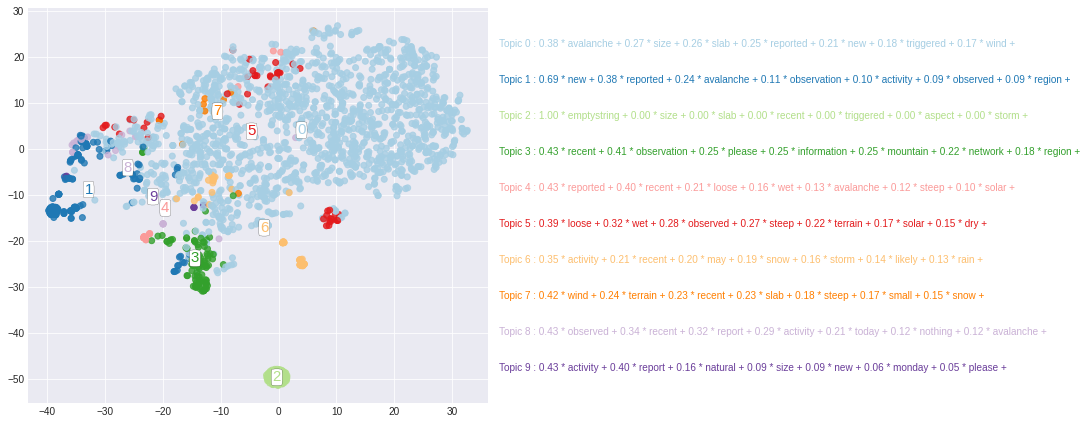

In [ ]:
cmap = matplotlib.cm.get_cmap('Paired')
fig, ax = plt.subplots(1,2,figsize=(16,6))
n_topics=len(svd_model.components_)
lsa_keys = np.argmax(lsa_topic_sample, axis=1)
ax[0].scatter(x=tsne_lsa_vectors[:,0],y=tsne_lsa_vectors[:,1], color=[cmap(i) for i in lsa_keys], alpha=0.8)
bbox_props = dict(boxstyle="round4,pad=0.1", lw=0.2, fc="white")
for i in range(n_topics):
    m = tsne_lsa_vectors[lsa_keys==i, :].mean(axis=0)
    ax[0].text(m[0], m[1], str(i), ha="center", va="center",
               size=15, color=cmap(i),
               bbox=bbox_props)
    ax[1].text(0,1-(i+1)*1/(n_topics+1),"Topic " + str(i) + " : "+ comp_label[i],ha="left", va="center", color=cmap(i))
    ax[1].axis('off')
fig.tight_layout()

In [ ]:
# LDA
import gensim
# gensim works with a list of lists of tokens
text_data = [text_prep(txt) for txt in forecasts.avalancheSummary]
# convert to bag of words
dictionary = gensim.corpora.Dictionary(text_data)
bow_data = [dictionary.doc2bow(text) for text in text_data]
ldamodel = gensim.models.ldamodel.LdaModel(bow_data, num_topics = 5, id2word=dictionary, passes=15)
topics = ldamodel.print_topics(num_words=10)
for topic in topics:
    print(topic)

(0, '0.083*"avalanche" + 0.050*"observation" + 0.049*"new" + 0.042*"reported" + 0.032*"mountain" + 0.030*"information" + 0.030*"region" + 0.025*"network" + 0.020*"please" + 0.018*"recent"')
(1, '0.061*"size" + 0.057*"slab" + 0.048*"avalanche" + 0.028*"triggered" + 0.025*"aspect" + 0.025*"wind" + 0.022*"storm" + 0.021*"reported" + 0.021*"natural" + 0.017*"skier"')
(2, '0.058*"avalanche" + 0.029*"persistent" + 0.028*"layer" + 0.027*"size" + 0.026*"triggered" + 0.019*"large" + 0.018*"slab" + 0.018*"report" + 0.016*"weak" + 0.011*"snowpack"')
(3, '0.052*"avalanche" + 0.042*"slab" + 0.037*"wind" + 0.032*"storm" + 0.031*"snow" + 0.022*"new" + 0.018*"may" + 0.017*"activity" + 0.015*"likely" + 0.013*"expected"')
(4, '0.058*"avalanche" + 0.053*"loose" + 0.046*"wet" + 0.029*"size" + 0.025*"aspect" + 0.022*"steep" + 0.019*"cornice" + 0.019*"observed" + 0.019*"activity" + 0.019*"slab"')


In [ ]:
pip install pyLDAvis


     |████████████████████████████████| 1.7MB 23.5MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
    Preparing wheel metadata ... done
     |████████████████████████████████| 9.9MB 36.7MB/s 
     |████████████████████████████████| 15.3MB 268kB/s 
  Created wheel for pyLDAvis: filename=pyLDAvis-3.3.1-cp37-none-any.whl size=136870 sha256=6c4c6f325a7b5f14c72de76e662e4e375982207d6a3fdc015433ce70c3f604c5
  Stored in directory: /root/.cache/pip/wheels/a0/9c/fc/c6e00689d35c82cf96a8adc70edfe7ba7904374fdac3240ac2
Successfully built pyLDAvis
ERROR: tensorflow 2.4.1 has requirement numpy~=1.19.2, but you'll have numpy 1.20.3 which is incompatible.
ERROR: google-colab 1.0.0 has requirement pandas~=1.1.0; python_version >= "3.0", but you'll have pandas 1.2.4 which is incompatible.
ERROR: datascience 0.10.6 has requirement folium==0.2.1, but you'll have folium 0.8.3 which is incompatible.
ERROR: albumentations 

In [ ]:
pip install pyLDAvis.gensim

In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()
lda_display = pyLDAvis.gensim_models.prepare(ldamodel, bow_data, dictionary)
lda_display

/usr/local/lib/python3.7/dist-packages/past/types/oldstr.py:5: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated since Python 3.3,and in 3.9 it will stop working
  from collections import Iterable


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
1     -0.163175 -0.042759       1        1  36.537806
2     -0.115610  0.003088       2        1  22.881195
3      0.047854  0.228815       3        1  19.538557
4     -0.087817 -0.105075       4        1  13.726780
0      0.318749 -0.084070       5        1   7.315662, topic_info=          Term          Freq         Total Category  logprob  loglift
108      loose   5109.000000   5109.000000  Default  30.0000  30.0000
23   avalanche  30232.000000  30232.000000  Default  29.0000  29.0000
195        wet   3450.000000   3450.000000  Default  28.0000  28.0000
26         new   5335.000000   5335.000000  Default  27.0000  27.0000
22        wind   8996.000000   8996.000000  Default  26.0000  26.0000
..         ...           ...           ...      ...      ...      ...
272       time    245.459310    567.988186   Topic5  -5.1013   1.7762
534    however    269.318921    713.609593   Topic5  -5.0086   1.6407
14      report    572.661609   6457.354373   Topic5  -4.2542   0.1925
229       last    217.882303   1392.599796   Topic5  -5.2205   0.7602
51        snow    204.328544   5468.183704   Topic5  -5.2847  -0.6718

[377 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
882       5  0.997608          're
91        1  0.865507            1
91        2  0.022289            1
91        4  0.111825            1
55        1  0.885034        1-1.5
...     ...       ...          ...
1087      2  0.033087  wind-loaded
123       1  0.992273         work
123       2  0.007100         work
1355      5  0.994551        worth
1326      5  0.994253         year

[613 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[2, 3, 4, 5, 1])